In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [61]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)*((n_embd * block_size)**0.5) #0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01 #iso zero we leave a bit of entropy 
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # small but not zero
b2 = torch.randn(vocab_size, generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


tensor(0.0277) tensor(1.0024)
tensor(-0.0024) tensor(0.9844)


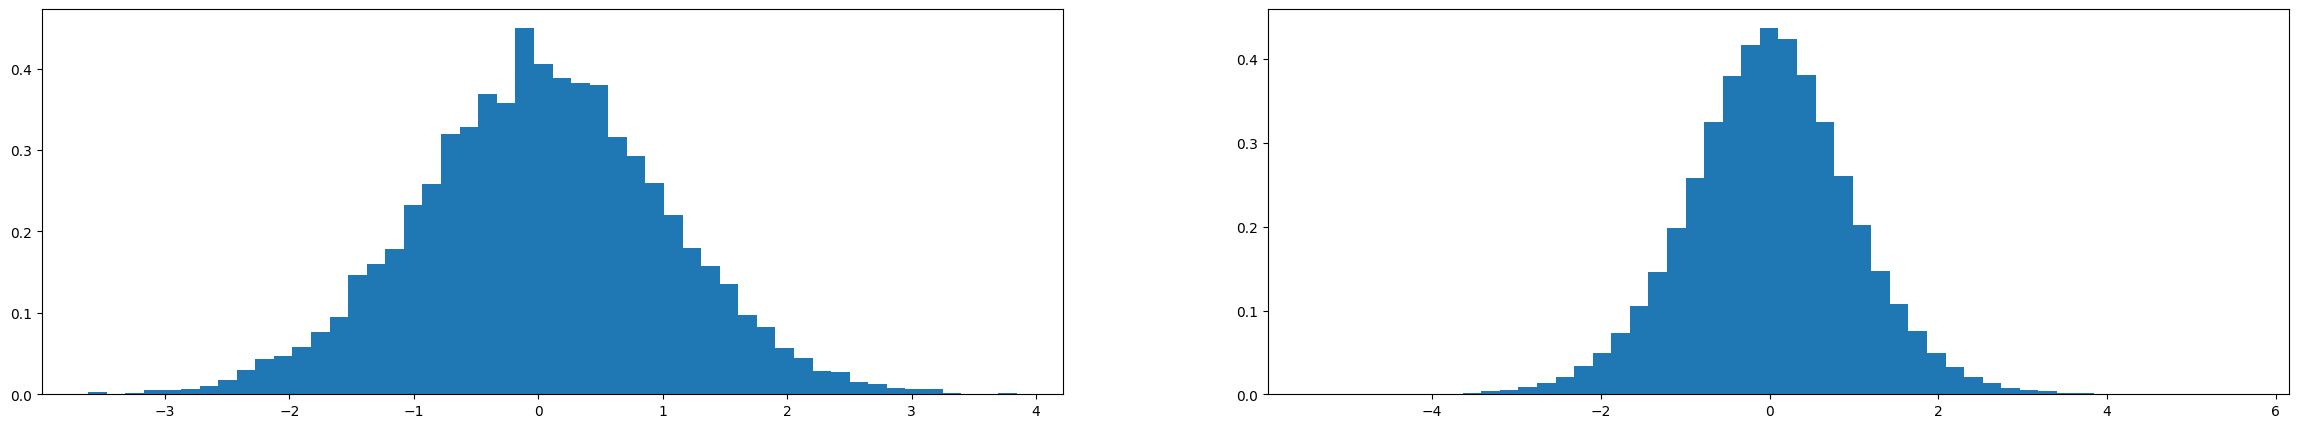

In [54]:
# we want data keep the initial distribution and std deviation (of 1) across the network
# this is done by dividing the w with the square of the inputs
# calculating the initial scale was before more important - now there are techniques that make this not so important
# scaling the network by the gain is needed as the activation functions take out big part of the data / distriburion
# each activation function has its own scaling factor
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(29,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

# Kaiming initialization (also known as He initialization) is a weight initialization technique designed to prevent 
# vanishing and exploding gradients in deep neural networks that use asymmetric activation functions like ReLU. 

# we want hpreact to be sort of gaussian with 0 mean and 1 std; this to match activation function tanh
# with tanh, hpreach is not too narrow (tanh inactive around 0) and not too large (tanh saturated on the flat tails)
# insight batch normalization paper: you have hidden states and would like to have the G(0,1), then normalize them to have them G(0,1)

In [62]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  
  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation

  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

# 0/ 200000: 3.3221 is closer to the value we expect

      0/ 200000: 3.3147
  10000/ 200000: 2.2387
  20000/ 200000: 2.4330
  30000/ 200000: 2.4949
  40000/ 200000: 1.9429
  50000/ 200000: 2.5044
  60000/ 200000: 2.4427
  70000/ 200000: 2.0587
  80000/ 200000: 2.3809
  90000/ 200000: 2.2332
 100000/ 200000: 2.1898
 110000/ 200000: 2.4085
 120000/ 200000: 2.1018
 130000/ 200000: 2.5740
 140000/ 200000: 2.4896
 150000/ 200000: 2.3274
 160000/ 200000: 2.0339
 170000/ 200000: 1.8523
 180000/ 200000: 2.2620
 190000/ 200000: 1.9991


In [34]:
logits[0] 
# you can see logits have quite extreme values -> fake confidence on incorrect answer -> loss high
# tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
  #        1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
   #      -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
    #     14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
     #  grad_fn=<SelectBackward0>)

tensor([-1.0116,  2.1188, -0.9094, -1.7597, -0.6278,  2.2488, -1.7701, -1.4847,
        -0.5791,  2.8137, -1.0658, -1.6276,  2.5373,  1.6568,  3.6743,  1.5284,
        -0.2121, -4.8727,  1.9167,  1.3214,  0.7041, -0.7861,  0.7666, -2.0710,
        -4.5282,  2.6770,  0.0309], grad_fn=<SelectBackward0>)

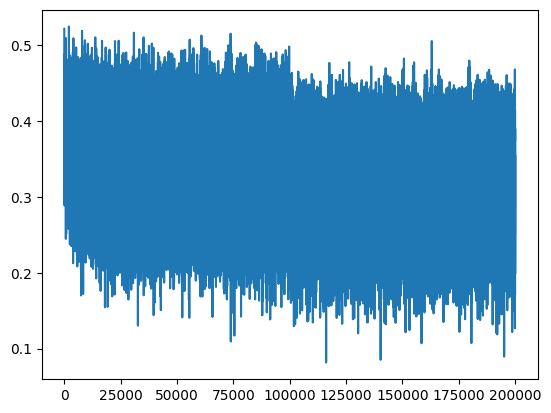

In [35]:
plt.plot(lossi) # hockey stick form smashed -> more iteration to optimise loss

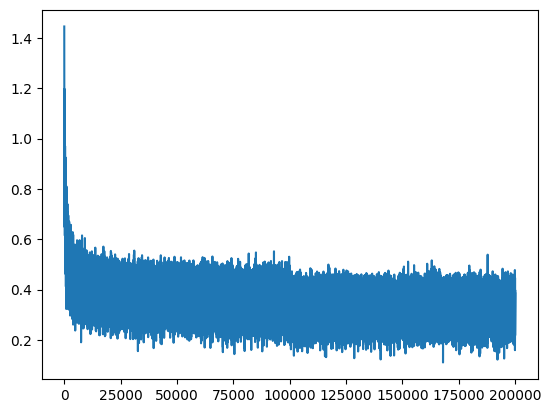

In [11]:
plt.plot(lossi)

In [63]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.173097610473633
val 2.1874232292175293


In [ ]:
# first iteration:
# train 2.1267659664154053
# val 2.1697638034820557

# 2nd iteration: fixing softmax confidently wrong
# train 2.0695888996124268
# val 2.131074905395508

# 3rd iteration: fixing saturated tanh
# train 2.0355966091156006
# val 2.1026782989501953

# 4th iteration: calculating initial scale
# train 2.1718497276306152
# val 2.205753803253174

# 5th iteration: batch normalization - here not so impactful as NN is simple and initial scale already shaped distribution as G(0,1)
# for big NN, difficult to setup initial scale, so batch normalization, which is implemented across the network, plays a critical role.
# train 2.173097610473633
# val 2.1874232292175293

In [13]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jore.
quint.
salin.
alianni.
wazthoniearyxi.
jace.
pirran.
eddeci.


In [14]:
# first thing to scrutinize is the initialization - initial loss is too high: 0/ 200000: 27.8817
# at initialisation, the probability distribution expected is unitiform, as each char has equal prob 1/27
# at init, NN is creating prob distr messed up: some char very confidently (wrongly), some char not confident
# we want the logits to be almost 0 (or all the same value) when the network is initialised - otherwise, loss explodes
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [19]:
# 4-dim example of the issue
#logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
logits = torch.randn(4)*10
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([-8.3453,  3.2991,  2.2845, 16.4673]),
 tensor([1.6750e-11, 1.9104e-06, 6.9260e-07, 1.0000e+00]),
 tensor(14.1828))

In [40]:
h.shape # 32 example and 200 activation for each example

torch.Size([32, 200])

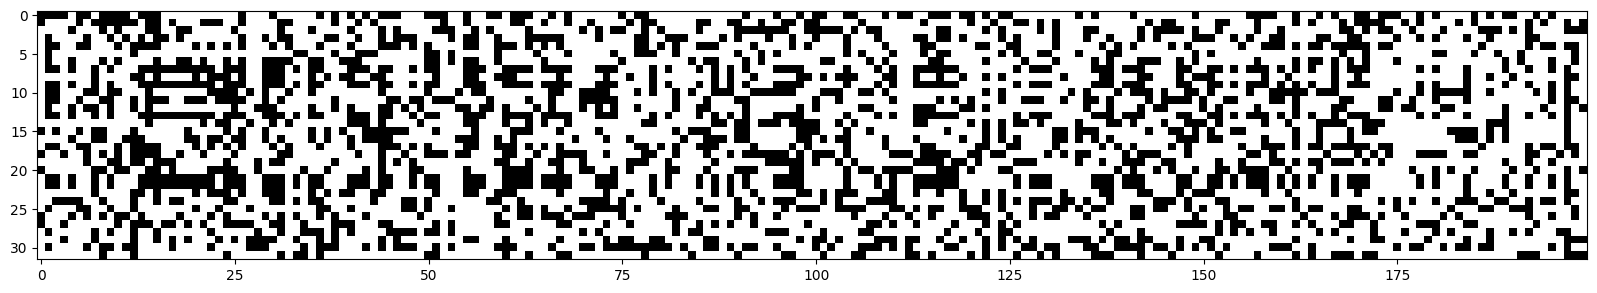

In [44]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation='nearest')
# h is quite activate, it can be seen by a lot of whites, destroying the gradient in the backprop
# if one full column is white is a big problem -> dead neuron (neuron will never learn)
# we intervene on hpreact and move W1 and b1 towards zero so that hpreact values are within a narrower range (below were bty -20, 20


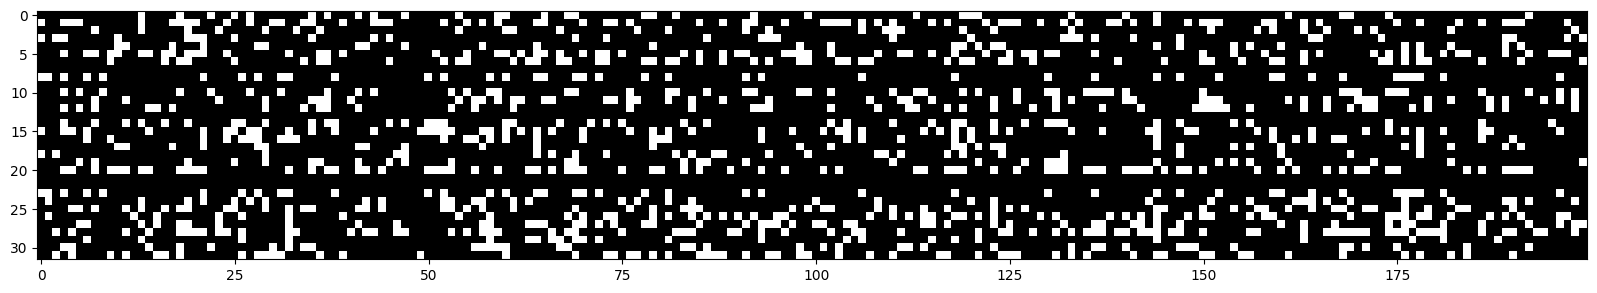

In [49]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation='nearest')

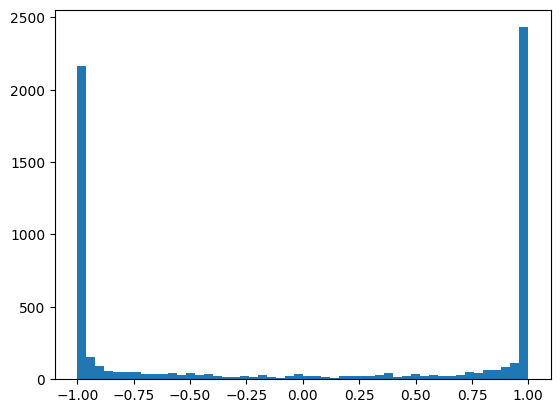

In [38]:
# 2nd point is about fixing the tanh saturated
# tanh is very active - histogram showes a lot of values -1 and 1
# value in flat part of tanh, so no change in outputs regardless of the change in inputs -> gradient get distroyed 
# mathematically, backpropagation comes with (1-t**2)* grad -> when t is -1 or 1, grad get blocked
plt.hist(h.view(-1).tolist(), 50);

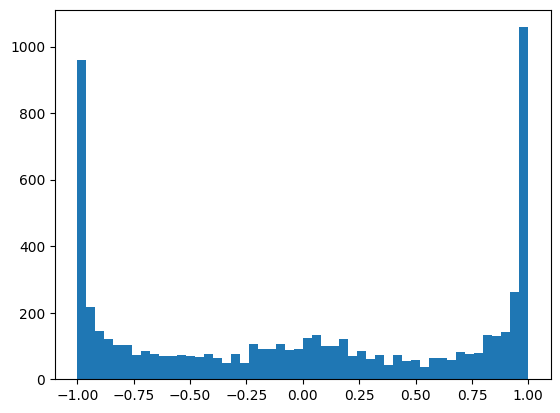

In [47]:
plt.hist(h.view(-1).tolist(), 50);

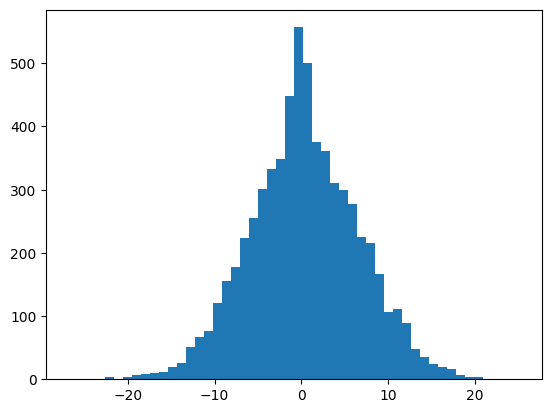

In [41]:
# distribution of pre-activation is very broad
plt.hist(hpreact.view(-1).tolist(), 50);

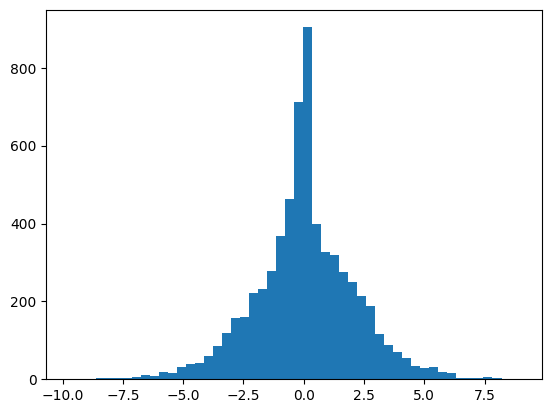

In [48]:
plt.hist(hpreact.view(-1).tolist(), 50);